# ArtBench-10 Student Starter Pack

This notebook is a starting template for class projects using **ArtBench-10**.

It covers:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `ArtBench-10/artbench-10-python/artbench-10-batches-py/`
- `ArtBench-10/ArtBench-10.csv`

If you do not have it on the folder, download from kaggle directly:

https://www.kaggle.com/datasets/alexanderliao/artbench10


In [2]:
from __future__ import annotations

import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Relative paths (run this notebook from student_start_pack/)
PROJECT_ROOT = Path('..')
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'

if not KAGGLE_ROOT.exists() or not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        'Could not resolve project folders from relative paths. '
        'Run this notebook from student_start_pack/ or adjust PROJECT_ROOT.'
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('KAGGLE_ROOT  =', KAGGLE_ROOT)

PROJECT_ROOT = ..
KAGGLE_ROOT  = ../student_start_pack/ArtBench-10


In [4]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='../student_start_pack/ArtBench-10'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [5]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [6]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv` 

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [7]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# Build a train dataset/loader using exactly those IDs
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))


Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


## Visualize a sample grid

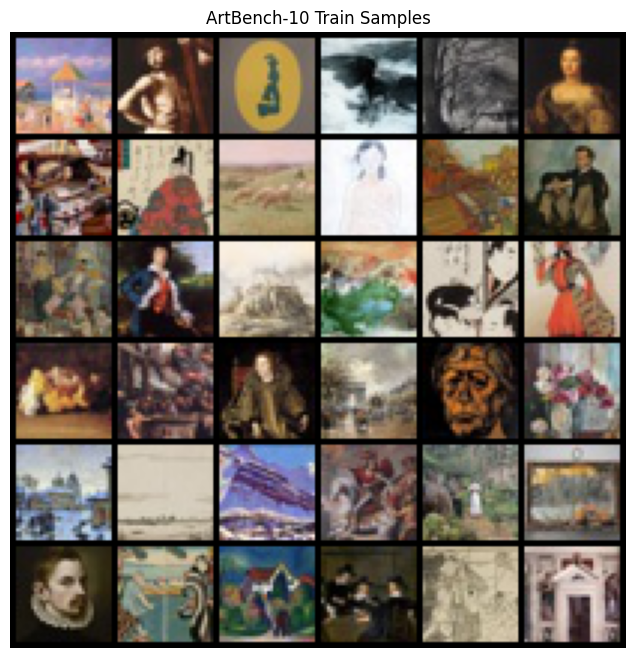

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e', 'expressionism', 'baroque', 'ukiyo_e', 'renaissance']


In [8]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [9]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(x[i], path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)


Exported 500 images to: exported_data/train_subset/images
Metadata CSV: exported_data/train_subset/metadata.csv


In [10]:
def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device('mps')
    return torch.device('cpu')

device=get_device()
print(device)

mps


## DCGAN (Deep Convolutional Generative Adversarial Networks)

In [11]:
import torch.nn as nn

class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100, image_channels=3, ngf=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, image_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        z = z.view(z.size(0), self.latent_dim, 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self, image_channels=3, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(image_channels, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


def init_dcgan_weights(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

def plot_gan_losses(history, title='GAN losses'):
    plt.figure(figsize=(7, 4))
    plt.plot(history['d_loss'], label='Discriminator loss')
    plt.plot(history['g_loss'], label='Generator loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def save_checkpoint(generator, discriminator, history, checkpoint_path, latent_dim, channels, image_size):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            'generator': generator.state_dict(),
            'discriminator': discriminator.state_dict(),
            'history': history,
            'config': {
                'latent_dim': latent_dim,
                'channels': channels,
                'image_size': image_size,
            },
        },
        checkpoint_path,
    )
    print('Saved checkpoint to', checkpoint_path)


@torch.no_grad()
def load_dcgan_generator_for_inference(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    cfg = ckpt['config']
    generator = DCGenerator(latent_dim=cfg['latent_dim'], image_channels=cfg['channels']).to(device)
    generator.load_state_dict(ckpt['generator'])
    generator.eval()
    return generator, cfg, ckpt.get('history', None)


In [20]:
from tqdm.auto import tqdm

def train_gan(generator, discriminator, loader, latent_dim, epochs=20, lr=2e-4):
    criterion = nn.BCELoss()
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    history = {'g_loss': [], 'd_loss': []}
    generator.train()
    discriminator.train()

    for epoch in range(epochs):
        g_running = 0.0
        d_running = 0.0
        n_batches = 0

        for batch in tqdm(loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False):
            real = batch[0].to(device)
            bs = real.size(0)

            real_targets = torch.ones(bs, 1, device=device)
            fake_targets = torch.zeros(bs, 1, device=device)
            opt_d.zero_grad()
            d_real=criterion(discriminator(real),real_targets)
            z =torch.randn(bs,latent_dim,device=device)
            fake=generator(z)
            d_loss_fake=criterion(discriminator(fake.detach()),fake_targets)
            d_loss= d_real + d_loss_fake
            d_loss.backward()
            opt_d.step()

           
            opt_g.zero_grad()
            z = torch.randn(bs,latent_dim,device=device)
            fake=generator(z)
            g_loss = criterion(discriminator(fake),real_targets)
            g_loss.backward()
            opt_g.step()

       
            g_running += g_loss.item()
            d_running += d_loss.item()
            n_batches += 1

        history['g_loss'].append(g_running / max(n_batches, 1))
        history['d_loss'].append(d_running / max(n_batches, 1))

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"D loss: {history['d_loss'][-1]:.4f} | "
            f"G loss: {history['g_loss'][-1]:.4f}"
        )

    return history

Epoch 1/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 01/20 | D loss: 0.6114 | G loss: 3.4607


Epoch 2/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 02/20 | D loss: 0.7210 | G loss: 2.7839


Epoch 3/20:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 18/20 | D loss: 0.8740 | G loss: 1.8260


Epoch 19/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 19/20 | D loss: 0.8636 | G loss: 1.8669


Epoch 20/20:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 20/20 | D loss: 0.8907 | G loss: 1.8816


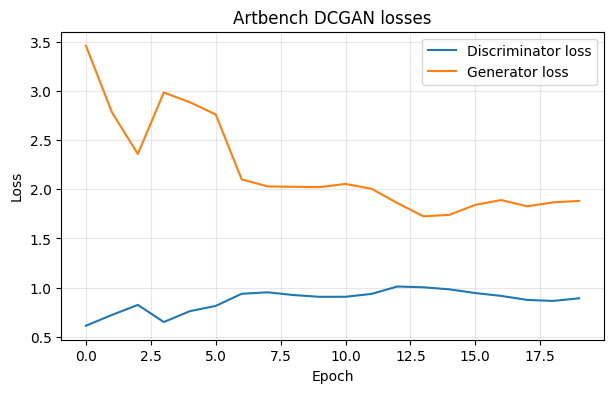

Saved checkpoint to models/artBenchDCGAN.pt


In [26]:
artBenchDCGAN_latent_dim = 100
artBenchDCGAN_epochs = 20
artBenchDCGAN_lr = 2e-4
artBenchDCGAN_channels=3

artBenchDCGAN_ckpt = Path('models/artBenchDCGAN.pt')

artBenchDCGAN_generator = DCGenerator(latent_dim=artBenchDCGAN_latent_dim,image_channels=artBenchDCGAN_channels,ngf=64).to(device)
artBenchDCGAN_discriminator = DCDiscriminator(image_channels=artBenchDCGAN_channels,ndf=64).to(device)

artBenchDCGAN_generator.apply(init_dcgan_weights)
artBenchDCGAN_discriminator.apply(init_dcgan_weights)

artBenchDCGAN_history = train_gan(
    generator=artBenchDCGAN_generator,
    discriminator=artBenchDCGAN_discriminator,
    loader=train_loader_from_csv,
    latent_dim=artBenchDCGAN_latent_dim,
    epochs=artBenchDCGAN_epochs,
    lr=artBenchDCGAN_lr,
)

plot_gan_losses(artBenchDCGAN_history, title='Artbench DCGAN losses')

save_checkpoint(
    generator=artBenchDCGAN_generator,
    discriminator=artBenchDCGAN_discriminator,
    history=artBenchDCGAN_history,
    checkpoint_path=artBenchDCGAN_ckpt,
    latent_dim=artBenchDCGAN_latent_dim,
    channels=artBenchDCGAN_channels,
    image_size=IMAGE_SIZE,
)

In [27]:
def denorm(x):
    return (x + 1.0) / 2.0

def show_image_grid(images, channels, title='Images', n_show=25):
    images = images[:n_show].detach().cpu()
    images = denorm(images).clamp(0, 1)

    n = images.size(0)
    grid = int(np.ceil(np.sqrt(n)))
    fig, axes = plt.subplots(grid, grid, figsize=(grid * 1.6, grid * 1.6))
    axes = np.atleast_2d(axes)

    idx = 0
    for i in range(grid):
        for j in range(grid):
            ax = axes[i, j]
            ax.axis('off')
            if idx < n:
                if channels == 1:
                    ax.imshow(images[idx, 0], cmap='gray', vmin=0, vmax=1)
                else:
                    ax.imshow(images[idx].permute(1, 2, 0))
            idx += 1

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [25]:
@torch.no_grad()
def run_inference(generator, latent_dim, channels, n_samples=25, seed=123, title='Generator inference'):
    torch.manual_seed(seed)
    z = torch.randn(n_samples,latent_dim,device=device)
    fake = generator(z)
    
    real_batch = next(iter(train_loader_from_csv))
    real = real_batch[0][:n_samples].to(device)

    show_image_grid(real,channels=channels,title='Real',n_show=n_samples)
    show_image_grid(fake, channels=channels, title=title, n_show=n_samples)
  

@torch.no_grad()
def latent_walk(generator, latent_dim, channels, steps=10, title='Latent interpolation'):
    z0 = torch.randn(1,latent_dim,device=device)
    z1 = torch.randn(1,latent_dim,device=device)
    alphas=torch.linspace(0,1,steps=steps,device=device).unsqueeze(1)
    z = (1-alphas)*z0 + alphas*z1
    fake = generator(z)

    show_image_grid(fake, channels=channels, title=title, n_show=steps)


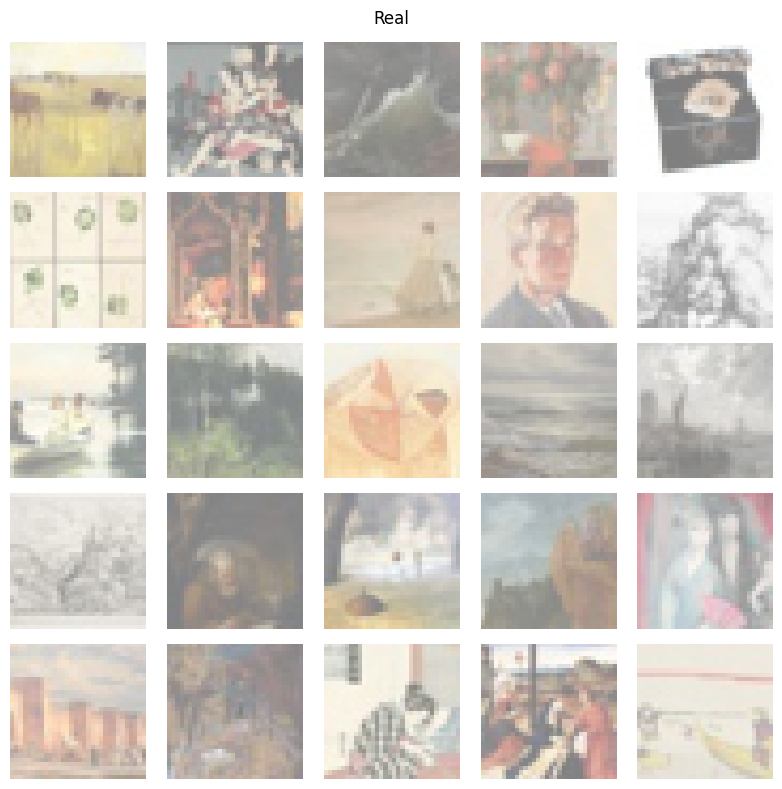

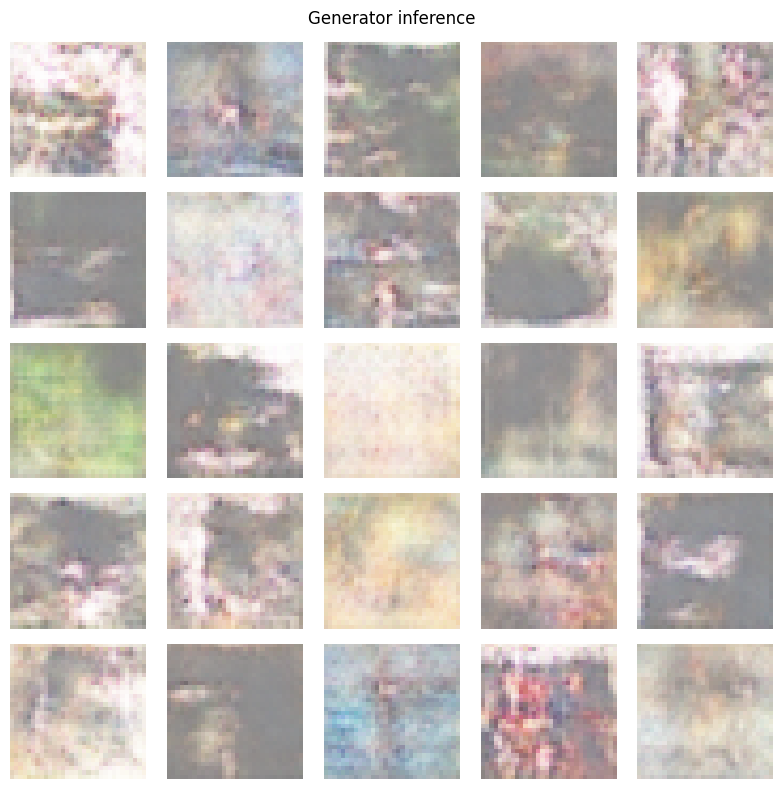

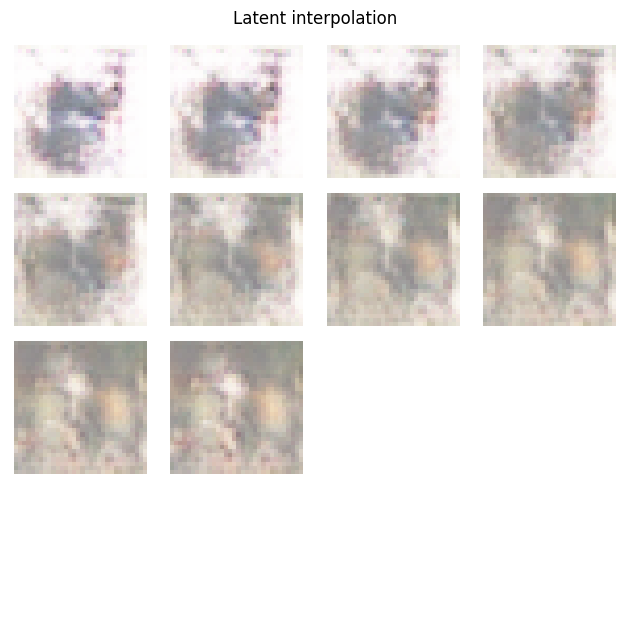

In [26]:
artBenchDCGAN_gen_infer, artBenchDCGAN_cfg, _ = load_dcgan_generator_for_inference('models/artBenchDCGAN.pt')

run_inference(generator=artBenchDCGAN_gen_infer,latent_dim=artBenchDCGAN_cfg['latent_dim'],channels=artBenchDCGAN_cfg['channels'])
latent_walk(generator=artBenchDCGAN_gen_infer,latent_dim=artBenchDCGAN_cfg['latent_dim'],channels=artBenchDCGAN_cfg['channels'],steps=10)
